In [4]:
from numpy.random import Generator, default_rng
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
import numpy as np
import simpy as sim
from scipy.optimize import root_scalar

In [5]:
class Bomb:
    def __init__(self,
                 t_erup: float,
                 r0: np.ndarray,
                 v0: np.ndarray,
                 mass: float,
                 radius: float,
                 bomb_id: int):
        self.t_erup = t_erup
        self.r = r0.copy()
        self.v = v0.copy()
        self.m = mass
        self.R = radius
        self.id = bomb_id
        self.collided = False
        self.fallen = False
        self.fall_time = None
        self.fall_position = None
        self.g = np.array([0, 0, -9.81])

    def calc_r(self, t: float) -> np.ndarray:
        tau = t - self.t_erup
        if tau < 0:
            return self.r
        return self.r + self.v * tau + 0.5 * self.g * tau**2

    def calc_v(self, t: float) -> np.ndarray:
        tau = t - self.t_erup
        if tau < 0:
            return self.v
        return self.v + self.g * tau

    def is_collided(self) -> bool:
        return self.collided

    def xy_fall(self) -> Optional[np.ndarray]:
        return self.fall_position[:2] if self.fall_position is not None else None

    def calculate_fall_time(self) -> float:
        z0 = self.r[2]
        v0z = self.v[2]
        gz = self.g[2]

        discriminant = v0z**2 - 2 * gz * z0

        if discriminant < 0:
            return float('inf')

        t1 = (-v0z - np.sqrt(discriminant)) / gz
        t2 = (-v0z + np.sqrt(discriminant)) / gz

        positive_times = [t for t in [t1, t2] if t > 0]
        return min(positive_times) if positive_times else float('inf')


In [6]:
flyings, fallens = [], []
processes: Dict[Bomb, List[sim.Process]] = {}

H = 800.0
D_c = 10.0
R_c = 5.0
mu_v = 60.0
sigma_v = 10.0
mu_theta = np.radians(80)
sigma_theta = np.radians(5)
R_min = 0.5
R_max = 1.0
rho = 2500.0
beta_erup = 0.1

rs_no_collision = default_rng(seed=42)
rs_with_collision = default_rng(seed=42)

bomb_counter = 0
allowed_collisions = True

=== Сравнение эффекта столкновений ===
Симуляция БЕЗ столкновений...
Завершено: 225 камней
Симуляция СО столкновениями...


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Завершено: 225 камней

=== СТАТИСТИКА ===
Модель БЕЗ столкновений: 225 камней
Модель СО столкновениями (без столкн.): 123 камней
Модель СО столкновениями (со столкн.): 102 камней
Произошло столкновений: 51
Процент столкнувшихся камней: 45.3%
Камни со столкновениями: 102


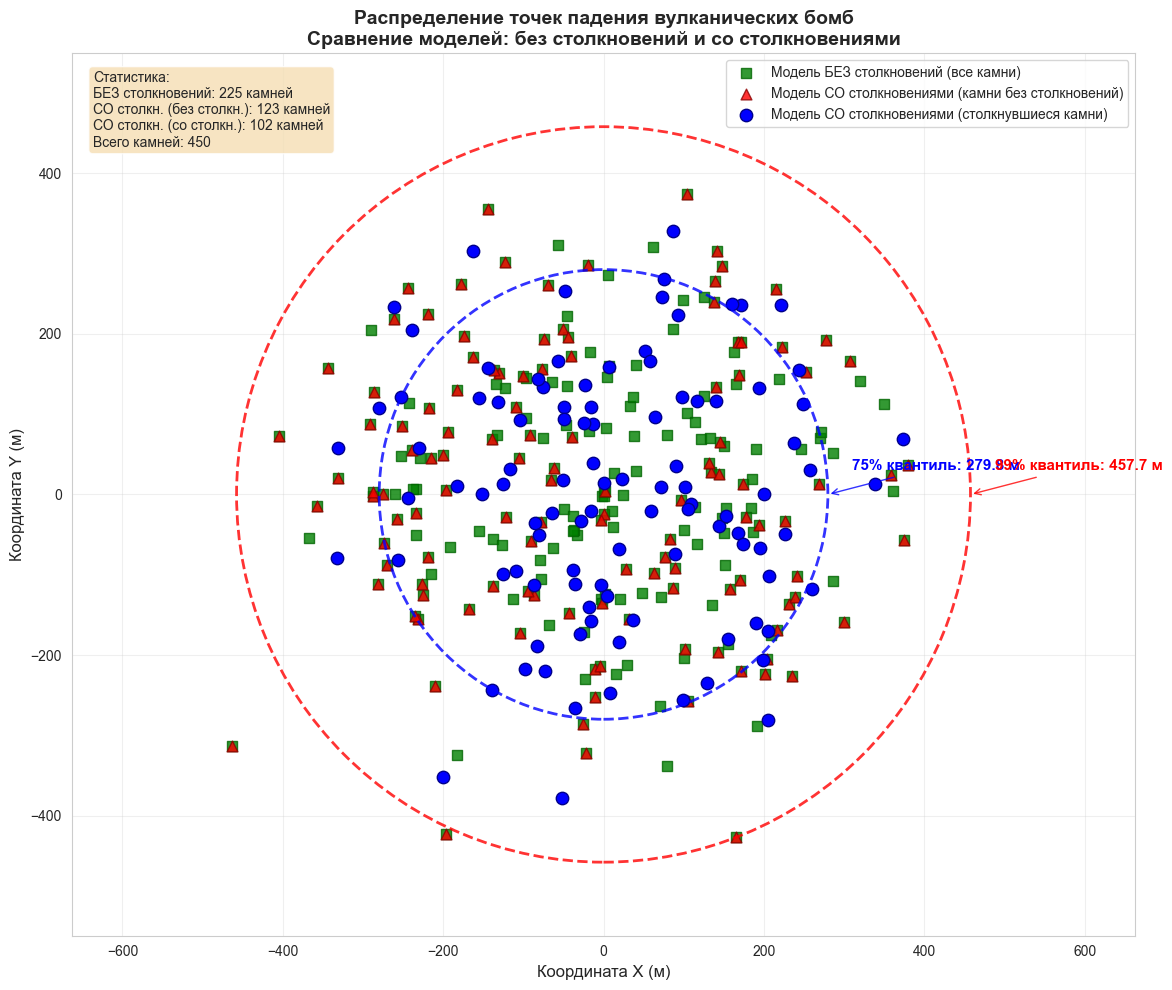

In [7]:
def generate_bomb_parameters(rs: Generator, bomb_id: int) -> Tuple[np.ndarray, np.ndarray, float, float]:
    d = rs.uniform(0, R_c)
    alpha = rs.uniform(0, 2 * np.pi)
    z0 = rs.uniform(H - D_c, H)

    r0 = np.array([
        d * np.cos(alpha),
        d * np.sin(alpha),
        z0
    ])

    v0_magnitude = rs.normal(mu_v, sigma_v)
    while v0_magnitude <= 0:
        v0_magnitude = rs.normal(mu_v, sigma_v)

    theta = rs.normal(mu_theta, sigma_theta)
    theta = np.clip(theta, np.radians(75), np.pi/2)
    phi = rs.uniform(0, 2 * np.pi)

    v0 = np.array([
        v0_magnitude * np.cos(theta) * np.cos(phi),
        v0_magnitude * np.cos(theta) * np.sin(phi),
        v0_magnitude * np.sin(theta)
    ])

    radius = rs.uniform(R_min, R_max)
    mass = rho * (4/3) * np.pi * radius**3

    return r0, v0, mass, radius

def eruption(env: sim.Environment, n_bombs: int, rs: Generator):
    global bomb_counter

    for i in range(n_bombs):
        r0, v0, mass, radius = generate_bomb_parameters(rs, bomb_counter)
        bomb = Bomb(env.now, r0, v0, mass, radius, bomb_counter)
        bomb_counter += 1

        flyings.append(bomb)

        processes[bomb] = []
        ground_process = env.process(when_ground(env, bomb))
        processes[bomb].append(ground_process)

        if allowed_collisions:
            for other_bomb in flyings[:-1]:
                if (other_bomb.id != bomb.id and not other_bomb.collided and
                    not other_bomb.fallen and other_bomb in flyings):
                    collision_process = env.process(when_collision(env, bomb, other_bomb))
                    processes[bomb].append(collision_process)

def gen_bombs(env: sim.Environment, n_eruptions: int, bombs_per_eruption: int, rs: Generator):
    for i in range(n_eruptions):
        if i > 0:
            dt = rs.exponential(beta_erup)
            yield env.timeout(dt)

        eruption(env, bombs_per_eruption, rs)

def collision_physics(b1: Bomb, b2: Bomb, t_collision: float):
    r1 = b1.calc_r(t_collision)
    r2 = b2.calc_r(t_collision)
    v1 = b1.calc_v(t_collision)
    v2 = b2.calc_v(t_collision)

    normal = r2 - r1
    distance = np.linalg.norm(normal)
    if distance == 0:
        normal = np.array([1.0, 0.0, 0.0])
    else:
        normal = normal / distance

    v_rel = v2 - v1

    e = 0.8

    j = -(1 + e) * np.dot(v_rel, normal) / (1/b1.m + 1/b2.m)

    b1.v = v1 - (j / b1.m) * normal
    b2.v = v2 + (j / b2.m) * normal

    separation = 1.2 * (b1.R + b2.R)
    direction = normal * separation / 2
    b1.r = r1 - direction
    b2.r = r2 + direction

    b1.t_erup = t_collision
    b2.t_erup = t_collision

    b1.collided = True
    b2.collided = True

def when_ground(env: sim.Environment, bomb: Bomb):
    try:
        fall_time = bomb.calculate_fall_time()
        if fall_time < float('inf') and fall_time > 0 and not bomb.fallen:
            yield env.timeout(fall_time)

            if bomb in flyings and not bomb.fallen:
                fall_position = bomb.calc_r(env.now)
                bomb.fall_position = fall_position
                bomb.fall_time = env.now
                bomb.fallen = True

                if bomb in flyings:
                    flyings.remove(bomb)
                    fallens.append(bomb)

                clear_queue(bomb)
    except sim.Interrupt:
        return

def collision_distance(t: float, b1: Bomb, b2: Bomb) -> float:
    r1 = b1.calc_r(t)
    r2 = b2.calc_r(t)
    distance = np.linalg.norm(r2 - r1)
    return distance - (b1.R + b2.R)

def find_collision_time(b1: Bomb, b2: Bomb, current_time: float, max_search_time: float = 20.0) -> float:
    try:
        times = np.linspace(current_time, current_time + max_search_time, 100)
        for t in times:
            if collision_distance(t, b1, b2) <= 0:
                low = current_time
                high = t
                for _ in range(10):
                    mid = (low + high) / 2
                    if collision_distance(mid, b1, b2) <= 0:
                        high = mid
                    else:
                        low = mid
                return (low + high) / 2

        return float('inf')

    except:
        return float('inf')

def when_collision(env: sim.Environment, b1: Bomb, b2: Bomb):
    try:
        if (b1 not in flyings or b2 not in flyings or
            b1.fallen or b2.fallen or
            b1.collided or b2.collided):
            return

        t_collision = find_collision_time(b1, b2, env.now)

        if t_collision < float('inf') and t_collision > env.now:
            wait_time = t_collision - env.now
            yield env.timeout(wait_time)

            if (b1 in flyings and b2 in flyings and
                not b1.collided and not b2.collided and
                not b1.fallen and not b2.fallen):

                collision_physics(b1, b2, t_collision)

                clear_queue(b1)
                clear_queue(b2)

                processes[b1] = [env.process(when_ground(env, b1))]
                processes[b2] = [env.process(when_ground(env, b2))]

    except sim.Interrupt:
        return

def clear_queue(bomb: Bomb):
    if bomb in processes:
        for proc in processes[bomb]:
            if proc.is_alive:
                try:
                    proc.interrupt()
                except:
                    pass
        processes[bomb] = []

def simulate(env: sim.Environment, n_eruptions: int, bombs_per_eruption: int, rs: Generator, allowed_collisions_param: bool = True):
    global flyings, fallens, processes, bomb_counter, allowed_collisions
    flyings, fallens = [], []
    processes = {}
    bomb_counter = 0
    allowed_collisions = allowed_collisions_param

    env.process(gen_bombs(env, n_eruptions, bombs_per_eruption, rs))
    env.run()

def plot_combined_fall_distribution(fallens_no_collision, fallens_with_collision):
    if not fallens_no_collision and not fallens_with_collision:
        print("Нет данных для визуализации")
        return None, None

    fig, ax = plt.subplots(figsize=(12, 10))

    all_positions = []

    positions_no_collision = []
    for bomb in fallens_no_collision:
        xy = bomb.xy_fall()
        if xy is not None:
            positions_no_collision.append(xy)
            all_positions.append(xy)

    if positions_no_collision:
        positions_no_collision = np.array(positions_no_collision)
        ax.scatter(positions_no_collision[:, 0], positions_no_collision[:, 1],
                  c='green', s=60, alpha=0.8, label='Модель БЕЗ столкновений (все камни)',
                  marker='s', edgecolors='darkgreen')

    positions_with_collision_no_collided = []
    positions_with_collision_collided = []

    for bomb in fallens_with_collision:
        xy = bomb.xy_fall()
        if xy is not None:
            all_positions.append(xy)
            if bomb.collided:
                positions_with_collision_collided.append(xy)
            else:
                positions_with_collision_no_collided.append(xy)

    if positions_with_collision_no_collided:
        positions_with_collision_no_collided = np.array(positions_with_collision_no_collided)
        ax.scatter(positions_with_collision_no_collided[:, 0], positions_with_collision_no_collided[:, 1],
                  c='red', s=60, alpha=0.8, label='Модель СО столкновениями (камни без столкновений)',
                  marker='^', edgecolors='darkred')

    if positions_with_collision_collided:
        positions_with_collision_collided = np.array(positions_with_collision_collided)
        ax.scatter(positions_with_collision_collided[:, 0], positions_with_collision_collided[:, 1],
                  c='blue', s=80, alpha=1.0, label='Модель СО столкновениями (столкнувшиеся камни)',
                  marker='o', edgecolors='darkblue')
        print(f"Камни со столкновениями: {len(positions_with_collision_collided)}")

    if not all_positions:
        print("Нет позиций падения для визуализации")
        return None, None

    all_positions_array = np.array(all_positions)
    distances = np.sqrt(all_positions_array[:, 0]**2 + all_positions_array[:, 1]**2)
    quantile_75 = np.quantile(distances, 0.75)
    quantile_99 = np.quantile(distances, 0.99)

    circle_75 = plt.Circle((0, 0), quantile_75, fill=False,
                          color='blue', linestyle='--', linewidth=2, alpha=0.8)
    circle_99 = plt.Circle((0, 0), quantile_99, fill=False,
                          color='red', linestyle='--', linewidth=2, alpha=0.8)

    ax.add_patch(circle_75)
    ax.add_patch(circle_99)

    ax.set_xlabel('Координата X (м)', fontsize=12)
    ax.set_ylabel('Координата Y (м)', fontsize=12)
    ax.set_title('Распределение точек падения вулканических бомб\nСравнение моделей: без столкновений и со столкновениями',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')
    ax.axis('equal')

    ax.annotate(f'75% квантиль: {quantile_75:.1f} м',
                xy=(quantile_75, 0), xytext=(quantile_75 + 30, 30),
                arrowprops=dict(arrowstyle='->', color='blue', alpha=0.8),
                color='blue', fontsize=11, fontweight='bold')

    ax.annotate(f'99% квантиль: {quantile_99:.1f} м',
                xy=(quantile_99, 0), xytext=(quantile_99 + 30, 30),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.8),
                color='red', fontsize=11, fontweight='bold')

    max_range = max(quantile_99 * 1.2, np.max(np.abs(all_positions_array)) * 1.1, 100)
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)

    collided_count = len(positions_with_collision_collided)
    non_collided_count = len(positions_with_collision_no_collided)

    stats_text = (f"Статистика:\n"
                 f"БЕЗ столкновений: {len(fallens_no_collision)} камней\n"
                 f"СО столкн. (без столкн.): {non_collided_count} камней\n"
                 f"СО столкн. (со столкн.): {collided_count} камней\n"
                 f"Всего камней: {len(fallens_no_collision) + len(fallens_with_collision)}")

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    return fig, ax

def compare_collision_effects():
    n_eruptions = 15
    bombs_per_eruption = 15

    print("=== Сравнение эффекта столкновений ===")

    print("Симуляция БЕЗ столкновений...")
    global flyings, fallens, processes, bomb_counter

    flyings, fallens = [], []
    processes = {}
    bomb_counter = 0

    env_no_collision = sim.Environment()
    simulate(env_no_collision, n_eruptions, bombs_per_eruption, rs_no_collision, False)
    fallens_no_collision = fallens.copy()
    print(f"Завершено: {len(fallens_no_collision)} камней")

    print("Симуляция СО столкновениями...")
    flyings, fallens = [], []
    processes = {}
    bomb_counter = 0

    env_with_collision = sim.Environment()
    simulate(env_with_collision, n_eruptions, bombs_per_eruption, rs_with_collision, True)
    fallens_with_collision = fallens.copy()
    print(f"Завершено: {len(fallens_with_collision)} камней")

    collided_count = sum(1 for b in fallens_with_collision if b.collided)
    non_collided_count = sum(1 for b in fallens_with_collision if not b.collided)
    collision_pairs = collided_count // 2

    print(f"\n=== СТАТИСТИКА ===")
    print(f"Модель БЕЗ столкновений: {len(fallens_no_collision)} камней")
    print(f"Модель СО столкновениями (без столкн.): {non_collided_count} камней")
    print(f"Модель СО столкновениями (со столкн.): {collided_count} камней")
    print(f"Произошло столкновений: {collision_pairs}")
    print(f"Процент столкнувшихся камней: {collided_count/len(fallens_with_collision)*100:.1f}%")

    plot_combined_fall_distribution(fallens_no_collision, fallens_with_collision)
    plt.show()

if __name__ == "__main__":
    compare_collision_effects()